# Verificación de los resultados publicados

Este notebook toma **únicamente los archivos publicados en
`results/student_paper_oficial/`** y muestra cómo cada número del Student Paper
se deriva de ellos.

**Qué demuestra**

- que los artefactos no fueron alterados desde que se generaron;
- que las cifras del corpus y de la partición cierran entre sí;
- que las cuatro matrices de confusión de la ablación se reconstruyen contando
  las 8.597 predicciones individuales, una por una;
- que las métricas de la Tabla 1 salen de esas matrices;
- que la verificación detecta la alteración de una sola predicción.

**Qué NO demuestra**

No reentrena nada, así que no es prueba del entrenamiento en sí; para eso está
`src/fase5_6_entrenamiento.py`, que produjo estos artefactos. Tampoco responde
preguntas de método —agrupación por dominio o campaña, una sola semilla,
dificultad del corpus benigno—: eso está declarado en la sección de
Limitaciones del paper.

**Requisitos**: ninguno. Solo biblioteca estándar de Python 3. Corre en
segundos.

In [1]:
import csv
import hashlib
import json
from pathlib import Path


def localizar_resultados():
    """Funciona tanto si se abre desde notebooks/ como desde la raiz del repo."""
    for base in (Path.cwd(), *Path.cwd().parents):
        candidato = base / "results" / "student_paper_oficial"
        if candidato.is_dir():
            return candidato
    raise FileNotFoundError("No encuentro results/student_paper_oficial")


RESULTADOS = localizar_resultados()
print(f"Artefactos en: {RESULTADOS}")
print()
for archivo in sorted(RESULTADOS.iterdir()):
    print(f"  {archivo.stat().st_size:>9,} B   {archivo.name}")

Artefactos en: C:\Users\juani\Facu\3er año\practicas integradoras\cacic2026_codex_workspace\repo-oficial\results\student_paper_oficial

      1,149 B   config_modelo.json
        660 B   MANIFIESTO_SHA256.json
      1,698 B   matrices_ablacion.json
     28,125 B   matriz_confusion.png
        455 B   metricas_hibrido.json
    136,006 B   predicciones_test.csv
      1,153 B   README.md
        120 B   resumen_corpus.json
        499 B   tabla_ablacion.csv


## 1. Integridad

`MANIFIESTO_SHA256.json` guarda el hash de cada artefacto. Si alguno se hubiera
editado después de generarse, el hash no coincidiría.

In [2]:
manifiesto = json.loads((RESULTADOS / "MANIFIESTO_SHA256.json").read_text(encoding="utf-8"))

print(f"{'archivo':<26} {'esperado':<14} {'calculado':<14} ok")
print("-" * 60)
todo_integro = True
for nombre, esperado in manifiesto.items():
    calculado = hashlib.sha256((RESULTADOS / nombre).read_bytes()).hexdigest()
    coincide = calculado == esperado
    todo_integro = todo_integro and coincide
    print(f"{nombre:<26} {esperado[:12]:<14} {calculado[:12]:<14} {'si' if coincide else 'NO'}")

print()
print(f"Los {len(manifiesto)} artefactos coinciden con el manifiesto: {todo_integro}")

archivo                    esperado       calculado      ok
------------------------------------------------------------
resumen_corpus.json        18717e5ddee4   18717e5ddee4   si
tabla_ablacion.csv         0033d690d62c   0033d690d62c   si
matriz_confusion.png       5c8967e866f0   5c8967e866f0   si
metricas_hibrido.json      2bddfb295ae6   2bddfb295ae6   si
config_modelo.json         87d2c96b23c4   87d2c96b23c4   si
matrices_ablacion.json     a2170accfc29   a2170accfc29   si
predicciones_test.csv      b871bfad9e9b   b871bfad9e9b   si

Los 7 artefactos coinciden con el manifiesto: True


## 2. Las cifras del corpus cierran

El paper declara 57.309 páginas (39.684 de phishing y 17.625 benignas),
repartidas en 40.116 / 8.596 / 8.597. Estas sumas son las que en la corrección
del 4 de agosto no cerraban.

In [3]:
resumen = json.loads((RESULTADOS / "resumen_corpus.json").read_text(encoding="utf-8"))
matrices_json = json.loads((RESULTADOS / "matrices_ablacion.json").read_text(encoding="utf-8"))

suma_clases = resumen["phishing"] + resumen["benignas"]
suma_split = resumen["train"] + resumen["val"] + resumen["test"]
suma_test = matrices_json["test_benignas"] + matrices_json["test_phishing"]

print(f"  phishing + benignas    = {resumen['phishing']:,} + {resumen['benignas']:,} = {suma_clases:,}")
print(f"  corpus declarado       = {resumen['total_paginas']:,}")
print(f"  cierran                : {suma_clases == resumen['total_paginas']}")
print()
print(f"  train + val + test     = {resumen['train']:,} + {resumen['val']:,} + {resumen['test']:,} = {suma_split:,}")
print(f"  corpus declarado       = {resumen['total_paginas']:,}")
print(f"  cierran                : {suma_split == resumen['total_paginas']}")
print()
print(f"  benignas + phishing    = {matrices_json['test_benignas']:,} + {matrices_json['test_phishing']:,} = {suma_test:,}")
print(f"  test declarado         = {matrices_json['test_total']:,}")
print(f"  cierran                : {suma_test == matrices_json['test_total']}")

  phishing + benignas    = 39,684 + 17,625 = 57,309
  corpus declarado       = 57,309
  cierran                : True

  train + val + test     = 40,116 + 8,596 + 8,597 = 57,309
  corpus declarado       = 57,309
  cierran                : True

  benignas + phishing    = 2,644 + 5,953 = 8,597
  test declarado         = 8,597
  cierran                : True


## 3. Las matrices se reconstruyen desde las predicciones

Esta es la comprobación central. `predicciones_test.csv` tiene la predicción de
cada uno de los 8.597 casos de test para los cuatro escenarios. Se cuentan los
aciertos y errores **uno por uno**, sin mirar las matrices publicadas, y recién
después se comparan.

In [4]:
COLUMNAS = {
    "Solo URL": "solo_url",
    "Solo HTML (TF-IDF)": "solo_html",
    "Solo Hipervinculos": "solo_hipervinculos",
    "Sistema Hibrido": "sistema_hibrido",
}

with (RESULTADOS / "predicciones_test.csv").open(encoding="utf-8", newline="") as fh:
    predicciones = list(csv.DictReader(fh))

print(f"Predicciones leidas : {len(predicciones):,}")
print(f"Indices distintos   : {len({f['indice_corpus'] for f in predicciones}):,}")
print(f"Reales phishing     : {sum(1 for f in predicciones if f['y_real'] == '1'):,}")
print(f"Reales benignas     : {sum(1 for f in predicciones if f['y_real'] == '0'):,}")


def reconstruir(columna, filas):
    """Cuenta TN/FP/FN/TP caso por caso. Misma logica que
    scripts/verificar_resultados.py:verify_predictions()."""
    conteo = {"TN": 0, "FP": 0, "FN": 0, "TP": 0}
    for fila in filas:
        real, predicho = int(fila["y_real"]), int(fila[columna])
        if real == 1:
            conteo["TP" if predicho == 1 else "FN"] += 1
        else:
            conteo["FP" if predicho == 1 else "TN"] += 1
    return conteo


publicadas = {e["escenario"]: e["matriz_confusion"] for e in matrices_json["escenarios"]}
reconstruidas = {nombre: reconstruir(col, predicciones) for nombre, col in COLUMNAS.items()}

print()
for nombre in COLUMNAS:
    r, p = reconstruidas[nombre], publicadas[nombre]
    print(f"{nombre}")
    print(f"    contada desde las predicciones : TN={r['TN']:<5} FP={r['FP']:<5} FN={r['FN']:<4} TP={r['TP']}")
    print(f"    publicada en el repositorio    : TN={p['TN']:<5} FP={p['FP']:<5} FN={p['FN']:<4} TP={p['TP']}")
    print(f"    coinciden                      : {r == p}")

matrices_ok = reconstruidas == publicadas
print()
print(f"Las cuatro matrices se reconstruyen exactamente: {matrices_ok}")

Predicciones leidas : 8,597
Indices distintos   : 8,597
Reales phishing     : 5,953
Reales benignas     : 2,644



Solo URL
    contada desde las predicciones : TN=2607  FP=37    FN=108  TP=5845
    publicada en el repositorio    : TN=2607  FP=37    FN=108  TP=5845
    coinciden                      : True
Solo HTML (TF-IDF)
    contada desde las predicciones : TN=2330  FP=314   FN=270  TP=5683
    publicada en el repositorio    : TN=2330  FP=314   FN=270  TP=5683
    coinciden                      : True
Solo Hipervinculos
    contada desde las predicciones : TN=1453  FP=1191  FN=270  TP=5683
    publicada en el repositorio    : TN=1453  FP=1191  FN=270  TP=5683
    coinciden                      : True
Sistema Hibrido
    contada desde las predicciones : TN=2631  FP=13    FN=66   TP=5887
    publicada en el repositorio    : TN=2631  FP=13    FN=66   TP=5887
    coinciden                      : True

Las cuatro matrices se reconstruyen exactamente: True


## 4. De las matrices salen las métricas de la Tabla 1

Se recalculan las cinco métricas desde cada matriz reconstruida y se comparan
con dos cosas: `tabla_ablacion.csv` y los valores tal como están **impresos en
el paper**.

In [5]:
def metricas_desde_matriz(m):
    """Mismas formulas que scripts/verificar_resultados.py:metrics_from_matrix()."""
    tn, fp, fn, tp = m["TN"], m["FP"], m["FN"], m["TP"]
    precision = tp / (tp + fp)
    exhaustividad = tp / (tp + fn)
    return {
        "exactitud": (tn + tp) / (tn + fp + fn + tp),
        "precision": precision,
        "exhaustividad": exhaustividad,
        "f1": 2 * precision * exhaustividad / (precision + exhaustividad),
        "tfp": fp / (fp + tn),
    }


# Tabla 1 del paper, transcrita tal cual esta impresa.
TABLA_PAPER = {
    "Solo URL":           ("98,31", "99,37", "98,19", "0,9877", "1,40"),
    "Solo HTML (TF-IDF)": ("93,21", "94,76", "95,46", "0,9511", "11,88"),
    "Solo Hipervinculos": ("83,01", "82,67", "95,46", "0,8861", "45,05"),
    "Sistema Hibrido":    ("99,08", "99,78", "98,89", "0,9933", "0,49"),
}
CAMPOS = ("exactitud", "precision", "exhaustividad", "f1", "tfp")

with (RESULTADOS / "tabla_ablacion.csv").open(encoding="utf-8", newline="") as fh:
    csv_oficial = {f["escenario"]: f for f in csv.DictReader(fh)}

paper_ok = True
csv_ok = True
for nombre in COLUMNAS:
    m = metricas_desde_matriz(reconstruidas[nombre])
    print(nombre)
    for campo, impreso in zip(CAMPOS, TABLA_PAPER[nombre]):
        crudo = m[campo] if campo == "f1" else m[campo] * 100
        formateado = (f"{crudo:.4f}" if campo == "f1" else f"{crudo:.2f}").replace(".", ",")
        igual_paper = formateado == impreso
        paper_ok = paper_ok and igual_paper
        del_csv = float(csv_oficial[nombre][campo])
        igual_csv = abs(del_csv - m[campo]) < 1e-12
        csv_ok = csv_ok and igual_csv
        print(f"    {campo:<14} recalculado {formateado:>8}   paper {impreso:>8}  {'si' if igual_paper else 'NO'}"
              f"   | csv {'si' if igual_csv else 'NO'}")
    print()

print(f"Coincide con lo impreso en la Tabla 1 : {paper_ok}")
print(f"Coincide con tabla_ablacion.csv       : {csv_ok}")

Solo URL
    exactitud      recalculado    98,31   paper    98,31  si   | csv si
    precision      recalculado    99,37   paper    99,37  si   | csv si
    exhaustividad  recalculado    98,19   paper    98,19  si   | csv si
    f1             recalculado   0,9877   paper   0,9877  si   | csv si
    tfp            recalculado     1,40   paper     1,40  si   | csv si

Solo HTML (TF-IDF)
    exactitud      recalculado    93,21   paper    93,21  si   | csv si
    precision      recalculado    94,76   paper    94,76  si   | csv si
    exhaustividad  recalculado    95,46   paper    95,46  si   | csv si
    f1             recalculado   0,9511   paper   0,9511  si   | csv si
    tfp            recalculado    11,88   paper    11,88  si   | csv si

Solo Hipervinculos
    exactitud      recalculado    83,01   paper    83,01  si   | csv si
    precision      recalculado    82,67   paper    82,67  si   | csv si
    exhaustividad  recalculado    95,46   paper    95,46  si   | csv si
    f1         

## 5. Los falsos negativos compartidos

Solo HTML y Solo Hipervínculos reportan la misma exhaustividad. El paper afirma
que la coincidencia en el total es fortuita pero que el solapamiento real no lo
es. Se comprueba desde las predicciones.

In [6]:
fn_html = {f["indice_corpus"] for f in predicciones
           if f["y_real"] == "1" and f["solo_html"] == "0"}
fn_links = {f["indice_corpus"] for f in predicciones
            if f["y_real"] == "1" and f["solo_hipervinculos"] == "0"}

comunes = fn_html & fn_links
phishing_test = sum(1 for f in predicciones if f["y_real"] == "1")
esperado_azar = len(fn_html) * len(fn_links) / phishing_test

print(f"Falsos negativos de Solo HTML           : {len(fn_html)}")
print(f"Falsos negativos de Solo Hipervinculos  : {len(fn_links)}")
print(f"Paginas donde fallan los dos            : {len(comunes)}")
print(f"Esperables si fueran independientes     : {esperado_azar:.1f}")
print(f"Jaccard                                 : {len(comunes) / len(fn_html | fn_links):.4f}")
print()
print(f"Que ambos den {len(fn_html)} es fortuito: nada lo obliga.")
print(f"Que compartan {len(comunes)} no lo es: son {len(comunes) / esperado_azar:.0f} veces lo que daria el azar.")
print("Hay un nucleo de paginas que ninguna de las dos vistas de contenido detecta.")

Falsos negativos de Solo HTML           : 270
Falsos negativos de Solo Hipervinculos  : 270
Paginas donde fallan los dos            : 108
Esperables si fueran independientes     : 12.2
Jaccard                                 : 0.2500

Que ambos den 270 es fortuito: nada lo obliga.
Que compartan 108 no lo es: son 9 veces lo que daria el azar.
Hay un nucleo de paginas que ninguna de las dos vistas de contenido detecta.


## 6. La verificación tiene dientes

Una comprobación que siempre pasa no prueba nada. Acá se altera **una sola**
predicción de las 8.597 y se muestra que la reconstrucción deja de coincidir.

El cambio ocurre solo en memoria: el archivo en disco no se toca.

In [7]:
caso = dict(predicciones[0])
antes = caso["solo_html"]
caso["solo_html"] = "0" if antes == "1" else "1"

print(f"Se altera 1 prediccion de {len(predicciones):,} (solo en memoria)")
print(f"  indice_corpus={caso['indice_corpus']}   solo_html: {antes} -> {caso['solo_html']}")
print()

manipuladas = [caso] + predicciones[1:]
conteo_manipulado = reconstruir("solo_html", manipuladas)
publicada = publicadas["Solo HTML (TF-IDF)"]

print(f"  reconstruida con el dato alterado : {conteo_manipulado}")
print(f"  publicada                         : {publicada}")
print(f"  coinciden                         : {conteo_manipulado == publicada}")
print()
deteccion_ok = conteo_manipulado != publicada
print(f"La verificacion detecta el cambio: {deteccion_ok}")

en_disco = hashlib.sha256((RESULTADOS / "predicciones_test.csv").read_bytes()).hexdigest()
print(f"SHA256 del archivo en disco: {en_disco[:16]}...  (intacto: {en_disco == manifiesto['predicciones_test.csv']})")

Se altera 1 prediccion de 8,597 (solo en memoria)
  indice_corpus=2   solo_html: 1 -> 0

  reconstruida con el dato alterado : {'TN': 2330, 'FP': 314, 'FN': 271, 'TP': 5682}
  publicada                         : {'TN': 2330, 'FP': 314, 'FN': 270, 'TP': 5683}
  coinciden                         : False

La verificacion detecta el cambio: True
SHA256 del archivo en disco: b871bfad9e9b4775...  (intacto: True)


## Resumen

In [8]:
comprobaciones = [
    ("Los artefactos coinciden con el manifiesto", todo_integro),
    ("Las clases suman el corpus", suma_clases == resumen["total_paginas"]),
    ("Train + validacion + test suman el corpus", suma_split == resumen["total_paginas"]),
    ("El test se descompone en benignas + phishing", suma_test == matrices_json["test_total"]),
    ("Las 4 matrices se reconstruyen desde las predicciones", matrices_ok),
    ("Las metricas recalculadas dan lo impreso en la Tabla 1", paper_ok),
    ("Las metricas coinciden con tabla_ablacion.csv", csv_ok),
    ("Alterar una prediccion rompe la verificacion", deteccion_ok),
]

for etiqueta, ok in comprobaciones:
    print(f"  [{'OK' if ok else 'FALLA'}]  {etiqueta}")

print()
print("TODO VERIFICA" if all(ok for _, ok in comprobaciones)
      else "HAY COMPROBACIONES QUE FALLAN")

  [OK]  Los artefactos coinciden con el manifiesto
  [OK]  Las clases suman el corpus
  [OK]  Train + validacion + test suman el corpus
  [OK]  El test se descompone en benignas + phishing
  [OK]  Las 4 matrices se reconstruyen desde las predicciones
  [OK]  Las metricas recalculadas dan lo impreso en la Tabla 1
  [OK]  Las metricas coinciden con tabla_ablacion.csv
  [OK]  Alterar una prediccion rompe la verificacion

TODO VERIFICA


## Opcional: redibujar la figura

Lo único que necesita una dependencia externa. Si matplotlib no está instalado,
la celda lo informa y no interrumpe nada: todo lo anterior ya corrió sin
instalar nada.

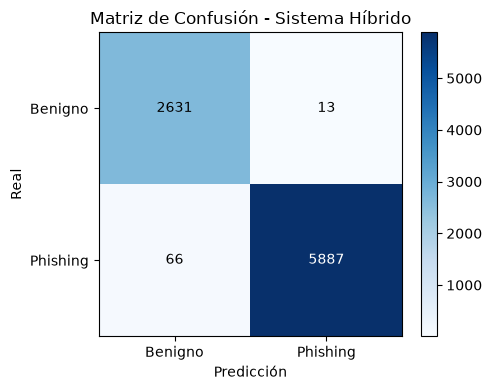

Reconstruida desde predicciones_test.csv, no cargada desde el PNG.


In [9]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("matplotlib no esta instalado; el resto del notebook no lo necesita.")
else:
    m = reconstruidas["Sistema Hibrido"]
    cm = [[m["TN"], m["FP"]], [m["FN"], m["TP"]]]
    maximo = max(max(fila) for fila in cm)

    fig, ax = plt.subplots(figsize=(5, 4))
    imagen = ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i][j]), ha="center", va="center",
                    color="white" if cm[i][j] > maximo / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Benigno", "Phishing"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Benigno", "Phishing"])
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
    ax.set_title("Matriz de Confusión - Sistema Híbrido")
    fig.colorbar(imagen)
    fig.tight_layout()
    plt.show()
    print("Reconstruida desde predicciones_test.csv, no cargada desde el PNG.")